In [1]:
# 1) GPU check — should print an A100/T4/L4, not an error
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-6f6086a5-4fa7-bbce-8b92-1bfe4d82f87d)


In [5]:
# 2) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 3) Copy the dataset local (Colab local disk is much faster than Drive)
import os, shutil
SRC = '/content/drive/MyDrive/light-footprint-removal/renders/footprint_dataset'
DST = '/content/data/footprint'
assert os.path.isdir(SRC), f'Dataset not found at {SRC} — check the Drive path!'
if not os.path.isdir(DST):
    shutil.copytree(SRC, DST)
print('frames:', len(os.listdir(f'{DST}/with/rgb')))

frames: 81


In [7]:
# 4) Build train/val/test splits: every 8th frame is HELD OUT of training.
# These held-out views are our honest novel-view evaluation later.
import json
root = '/content/data/footprint/with'
d = json.load(open('/content/data/footprint/transforms.json'))
frames = d['frames']
test_idx = set(range(0, len(frames), 8))
splits = {
    'train': [f for i, f in enumerate(frames) if i not in test_idx],
    'test':  [f for i, f in enumerate(frames) if i in test_idx],
}
splits['val'] = splits['test']
for name, fr in splits.items():
    out = {'camera_angle_x': d['camera_angle_x'], 'frames': fr}
    json.dump(out, open(f'{root}/transforms_{name}.json', 'w'), indent=2)
print({k: len(v) for k, v in splits.items()})

{'train': 70, 'test': 11, 'val': 11}


### Install nerfstudio
Takes ~5–15 minutes (it may compile the `gsplat` CUDA kernels once).
If the install cell finishes with errors about incompatible torch, run the cell
again — pip usually resolves on the second pass. After install, RESTART the
runtime if Colab asks, then re-run cells 2–4 (they're fast).

In [8]:
# 5) Install
!pip -q install nerfstudio
!ns-train --help | head -3   # sanity check the CLI exists

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 580.8/580.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.8 MB

In [9]:
# 6) Train splatfacto (3DGS). ~10-25 min depending on GPU.
!ns-train splatfacto \
  --data /content/data/footprint/with \
  --output-dir /content/outputs \
  --max-num-iterations 15000 \
  --viewer.quit-on-train-completion True \
  --vis tensorboard \
  blender-data

Streaming output truncated to the last 5000 lines.
-------------------------------------------------------------------------------------------------------- 
10830 (72.20%)      11.163 ms            46 s, 551.584 ms     35.83 M                                    
10840 (72.27%)      11.393 ms            47 s, 394.924 ms     35.14 M                                    
10850 (72.33%)      11.374 ms            47 s, 202.136 ms     35.18 M                                    
10860 (72.40%)      11.189 ms            46 s, 323.775 ms     35.73 M                                    
10870 (72.47%)      11.194 ms            46 s, 229.262 ms     35.69 M                                    
10880 (72.53%)      11.237 ms            46 s, 295.218 ms     35.58 M                                    
10890 (72.60%)      11.396 ms            46 s, 836.444 ms     35.13 M                                    
10900 (72.67%)      11.695 ms            47 s, 949.808 ms     34.45 M              27.17 M           

In [10]:
# 7) Find the run's config file (newest run wins)
import glob, os
configs = sorted(glob.glob('/content/outputs/**/config.yml', recursive=True),
                 key=os.path.getmtime)
CONFIG = configs[-1]
print(CONFIG)

/content/outputs/with/splatfacto/2026-08-07_191328/config.yml


In [12]:
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 ns-eval --load-config "$CONFIG" --output-path /content/eval_with.json
import json; print(json.load(open('/content/eval_with.json'))['results'])

2026-08-07 19:27:03.158048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-07 19:27:03.229640: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/usr/local/lib/python3.12/dist-packages/nerfstudio/field_components/activations.py:38: FutureWarning: `torc

2026-08-07 19:31:24.493165: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-07 19:31:24.563932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/usr/local/lib/python3.12/dist-packages/nerfstudio/field_components/activations.py:38: FutureWarning: `torc

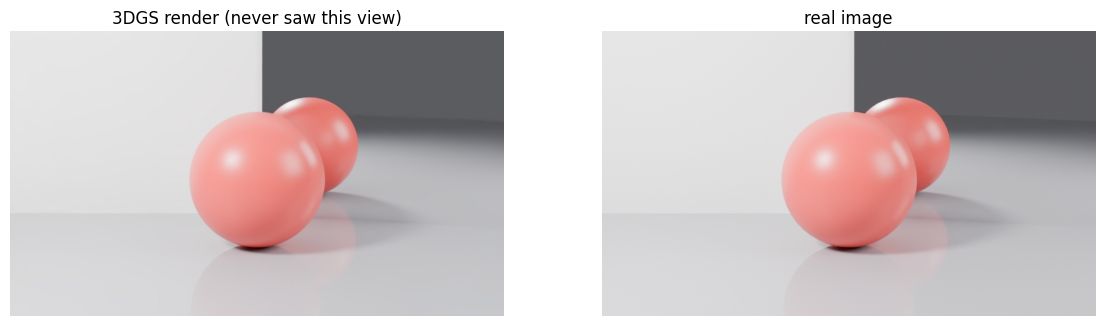

In [16]:
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 ns-render dataset --load-config "$CONFIG" --split test \
  --output-path /content/renders_test
import glob
from PIL import Image
import matplotlib.pyplot as plt

rgb = sorted(glob.glob('/content/renders_test/test/rgb/*.jpg'))
gt  = sorted(glob.glob('/content/renders_test/test/gt-rgb/*.jpg'))
print(len(rgb), 'renders,', len(gt), 'ground truths')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(Image.open(rgb[5])); ax[0].set_title('3DGS render (never saw this view)'); ax[0].axis('off')
ax[1].imshow(Image.open(gt[5]));  ax[1].set_title('real image');                        ax[1].axis('off')
plt.show()

In [17]:
# 10) Save model + eval back to Drive
import shutil, os
OUT = '/content/drive/MyDrive/light-footprint-removal/checkpoints/phase2_with'
os.makedirs(OUT, exist_ok=True)
shutil.copytree('/content/outputs', f'{OUT}/outputs', dirs_exist_ok=True)
shutil.copy('/content/eval_with.json', f'{OUT}/eval_with.json')
print('saved to', OUT)

saved to /content/drive/MyDrive/light-footprint-removal/checkpoints/phase2_with


### What success looks like
1. Cell 8 prints PSNR ≈ 30 or more on held-out views.
2. Cell 9's render is visually indistinguishable from the real frame — including
   the mirror image of the sphere (3DGS fakes reflections with view-dependent
   color, which is exactly why deleting the sphere's blobs won't delete its
   mirror image — the effect your whole project is about).

**Next phase after this works:** render a smooth orbit from this model
(that's the video for the editing step), and run the M1 baseline
(delete the sphere's Gaussians, measure what's left against the clean plate).

In [19]:
!pip -q install --force-reinstall "numpy==1.26.4"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires shapely>=2.1.0, but you have shapely 2.0.7 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.9.0 requires shapely>=2.1, but you have shapely 2.0.7 which is incompatible.
jaxlib 0

In [18]:
import os, json, numpy as np, torch, matplotlib.pyplot as plt
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
from pathlib import Path
from nerfstudio.utils.eval_utils import eval_setup
from nerfstudio.cameras.cameras import Cameras

_, pipeline, _, _ = eval_setup(Path(CONFIG))
meta = json.load(open('/content/data/footprint/transforms.json'))
W, H = 832, 480
fx = 0.5 * W / np.tan(0.5 * meta['camera_angle_x'])

def orbit_cam(theta_deg, height=1.5, radius=5.5):
    t = np.radians(theta_deg)
    eye    = np.array([radius*np.sin(t), 1.2 - radius*np.cos(t), height])
    target = np.array([0, 1.2, 0.6]); up = np.array([0, 0, 1.0])
    f = target - eye; f /= np.linalg.norm(f)
    r = np.cross(f, up); r /= np.linalg.norm(r)
    u = np.cross(r, f)
    return torch.tensor(np.stack([r, u, -f, eye], axis=1), dtype=torch.float32)[None]

views = {'inside the arc (30°)': 30, 'past the edge (100°)': 100, 'behind the scene (170°)': 170}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, th) in zip(axes, views.items()):
    cam = Cameras(camera_to_worlds=orbit_cam(th), fx=fx, fy=fx,
                  cx=W/2, cy=H/2, width=W, height=H).to(pipeline.device)
    with torch.no_grad():
        rgb = pipeline.model.get_outputs_for_camera(cam)['rgb'].cpu().numpy()
    ax.imshow(np.clip(rgb, 0, 1)); ax.set_title(name); ax.axis('off')
plt.show()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject